# Data Exploration & EDA
## California Property Close Price Prediction

This notebook contains exploratory data analysis (EDA) for the CRMLS sold listings dataset. We'll examine distributions, patterns, key fields, and data quality to inform preprocessing and modeling decisions.

**Project:** IDX Exchange — Summer 2026 Data Science Internship  
**Target Variable:** `ClosePrice` (final sale price)  
**Dataset:** Single-family residential properties in California

---
##  Setup & Data Loading

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
from pathlib import Path

# Point this to wherever you stored the CRMLSSold CSVs locally
DATA_DIR = Path.home()

FILE_MONTHS = [
    'CRMLSSold202511.csv',   # November 2025
    'CRMLSSold202512.csv',   # December 2025
    'CRMLSSold202601.csv',   # January 2026
    'CRMLSSold202602.csv',   # February 2026
    'CRMLSSold202603.csv',   # March 2026
    'CRMLSSold202604.csv',   # April 2026
    'CRMLSSold202605.csv',   # May 2026  ← held-out test set (Week 3)
]

frames = []
for fname in FILE_MONTHS:
    df_month = pd.read_csv(DATA_DIR / fname, low_memory=False)
    df_month['_source_file'] = fname
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)

df = raw[
    (raw['PropertyType'] == 'Residential') &
    (raw['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f'Loaded: {len(raw):,} total rows → {len(df):,} SFR rows')

Loaded: 143,492 total rows → 71,466 SFR rows


In [4]:
print(f'Rows after SFR filter : {len(df):,}')
print(f'Rows dropped (non-SFR): {len(raw) - len(df):,}')
print(f'SFR share of total    : {len(df)/len(raw)*100:.1f}%')

Rows after SFR filter : 71,466
Rows dropped (non-SFR): 72,026
SFR share of total    : 49.8%


In [5]:
# All remaining MlsStatus values should be 'Closed' — confirm
# Trestle: MlsStatus (MlsStatus Enum) — maps to StandardStatusprint('MlsStatus distribution in SFR set:')
print(df['MlsStatus'].value_counts())

MlsStatus distribution in SFR set:
MlsStatus
Closed    71466
Name: count, dtype: int64


In [6]:
raw.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,_source_file
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,5913.0,3.0,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,18432.0,NaN,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,5300.0,0.0,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,5272.0,1.0,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,10500.0,3.0,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv


In [7]:
df.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,_source_file
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,5913.0,3.0,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,18432.0,NaN,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,5300.0,0.0,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,5272.0,1.0,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,10500.0,3.0,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv


In [6]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,7.131400e+04,7.146600e+04,7.146600e+04,71457.000000,71457.000000,71432.000000,7.146600e+04,71466.000000,0.0,0.0,...,0.0,518.000000,0.0,63994.000000,7.024400e+04,43625.000000,68714.000000,51015.000000,7.023900e+04,0.0
mean,1.377403e+06,1.144602e+09,1.339923e+06,34.714612,-118.559103,2053.831846,1.265414e+06,41.758165,NaN,NaN,...,NaN,58.415058,NaN,1.352502,1.896649e+04,2.262877,2.006265,111.183889,4.813743e+05,NaN
std,8.346251e+06,1.358423e+07,7.387074e+06,1.788834,3.570638,1038.535401,1.512809e+06,56.980593,NaN,NaN,...,NaN,232.040664,NaN,0.477753,1.935028e+05,1.443249,3.465529,373.147289,2.122478e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.299000e+05,1.138431e+09,6.200000e+05,33.755208,-119.074101,1387.000000,6.238925e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.376000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.148842e+09,8.890000e+05,34.078986,-118.019069,1824.000000,8.890000e+05,20.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.020000e+03,3.000000,2.000000,0.000000,7.260000e+03,NaN
75%,1.430000e+06,1.153250e+09,1.420000e+06,34.701563,-117.252561,2451.000000,1.399000e+06,54.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.900000e+03,3.000000,2.000000,135.000000,1.045400e+04,NaN
max,1.302000e+09,1.171669e+09,7.960000e+08,43.784440,120.432670,31068.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.000000,1.938943e+09,NaN


In [7]:
df.dtypes

BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
                                 ...   
PostalCode                       object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
_source_file                     object
Length: 79, dtype: object

### Parsing Date Time Fields

In [8]:
# Trestle DateTime fields (agent-entered contractual dates, not MLS timestamps):
#   CloseDate              — date purchase agreement was fulfilled
#   ListingContractDate    — effective date of seller/broker agreement
#   PurchaseContractDate   — date offer was accepted, listing went off market
#   ContractStatusChangeDate — date of contractual status change
DATE_COLS = ['CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate']
for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['CloseYear']      = df['CloseDate'].dt.year
df['CloseMonth']     = df['CloseDate'].dt.month
df['CloseYearMonth'] = df['CloseDate'].dt.to_period('M')

---
## 1. Field Audit — Null Rates & Usability

Before any analysis, we audit every Trestle field for null rates to decide what is usable for modelling.

In [9]:
# Full missing value audit across all 78 columns
missing = (
    df.isnull().sum()
    .to_frame('null_count')
    .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(1))
    .sort_values('null_pct', ascending=False)
)
print('Fields with any missing values:')
display(missing[missing['null_count'] > 0])

Fields with any missing values:


,null_count,null_pct
CoveredSpaces,71466,100.0
TaxAnnualAmount,71466,100.0
AboveGradeFinishedArea,71466,100.0
FireplacesTotal,71466,100.0
TaxYear,71466,100.0
...,...,...
ListAgentAOR,19,0.0
BathroomsTotalInteger,1,0.0
City,14,0.0
PurchaseContractDate,3,0.0


In [10]:
# Classify fields by usability based on null rates
# Fields at 100% null are effectively absent from this CRMLS data extract
FULLY_NULL = [col for col in df.columns if df[col].isna().all()]
print(f'Fields with 100% null values ({len(FULLY_NULL)} total — drop from modelling):')
for col in sorted(FULLY_NULL):
    print(f'  {col}')

# Note: AboveGradeFinishedArea, BelowGradeFinishedArea, BuildingAreaTotal,
# TaxAnnualAmount, CoveredSpaces, FireplacesTotal, BusinessType,
# ElementarySchoolDistrict, MiddleOrJuniorSchoolDistrict are all 100% null
# in this CRMLS extract — not available for modelling.

Fields with 100% null values (8 total — drop from modelling):
  AboveGradeFinishedArea
  BusinessType
  CoveredSpaces
  ElementarySchoolDistrict
  FireplacesTotal
  MiddleOrJuniorSchoolDistrict
  TaxAnnualAmount
  TaxYear


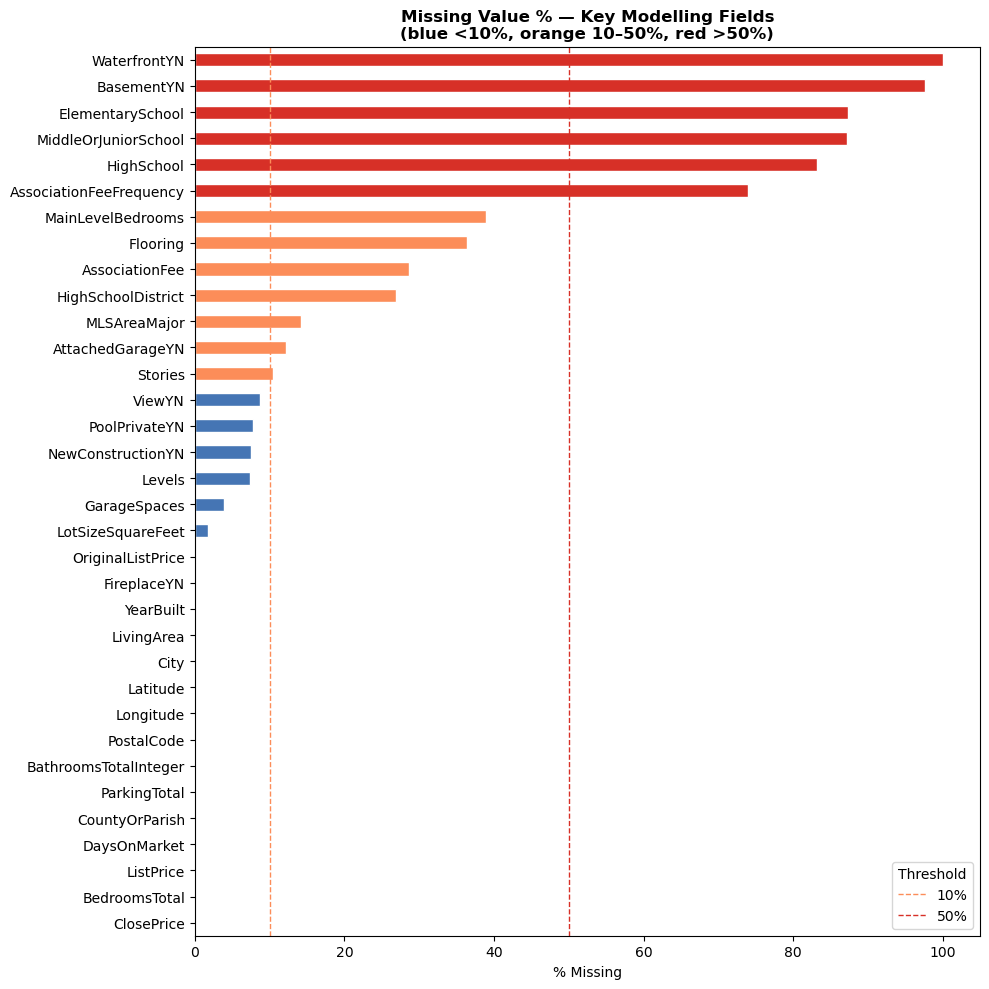

In [12]:
# Visual: missing % for the fields that ARE partially present
# Focus on key modelling candidates
KEY_COLS = [
    # Target
    'ClosePrice',
    # Core size (Trestle Decimal 14.2)
    'LivingArea', 'LotSizeSquareFeet',
    # Layout (Trestle Int32)
    'BedroomsTotal', 'BathroomsTotalInteger', 'Stories', 'MainLevelBedrooms',
    # Age
    'YearBuilt',
    # Pricing signal (Trestle Decimal 14.2)
    'ListPrice', 'OriginalListPrice',
    # Market timing (Trestle Int32)
    'DaysOnMarket',
    # Parking (Trestle Decimal 14.2)
    'GarageSpaces', 'ParkingTotal',
    # HOA (Trestle Decimal 14.2 / FeeFrequency Enum)
    'AssociationFee', 'AssociationFeeFrequency',
    # Boolean amenities
    'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN',
    'NewConstructionYN', 'WaterfrontYN', 'BasementYN',
    # Geography (Trestle String / Decimal)
    'PostalCode', 'CountyOrParish', 'City', 'MLSAreaMajor',
    'Latitude', 'Longitude',
    # Schools (Trestle String 50)
    'HighSchoolDistrict', 'HighSchool',
    'MiddleOrJuniorSchool', 'ElementarySchool',
    # Categorical
    'Levels', 'Flooring',
]

miss_pct = df[KEY_COLS].isnull().mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 10))
colors = miss_pct.map(lambda x: '#d73027' if x > 50 else ('#fc8d59' if x > 10 else '#4575b4'))
miss_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(10, color='#fc8d59', linestyle='--', linewidth=1, label='10%')
ax.axvline(50, color='#d73027', linestyle='--', linewidth=1, label='50%')
ax.set_title('Missing Value % — Key Modelling Fields\n(blue <10%, orange 10–50%, red >50%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% Missing')
ax.legend(title='Threshold')
plt.tight_layout()
plt.show()

In [13]:
# Summary table: modelling decision per field
field_decisions = {
    'LivingArea':            ('0.0%',  'Use as-is — total livable area (Decimal 14.2)'),
    'LotSizeSquareFeet':     ('1.7%',  'Impute with ZIP-level median — preferred over LotSizeAcres/LotSizeArea'),
    'BedroomsTotal':         ('0.0%',  'Use as-is — total bedrooms (Int32)'),
    'BathroomsTotalInteger': ('0.0%',  'Use as-is — simple sum of all bathrooms (Int32)'),
    'Stories':               ('10.5%', 'Impute with mode or group median — number of floors (Int32)'),
    'MainLevelBedrooms':     ('39.0%', 'High null rate — use cautiously or drop; may overlap with BedroomsTotal'),
    'YearBuilt':             ('0.1%',  'Engineer PropertyAge = 2026 - YearBuilt (Int32)'),
    'ListPrice':             ('0.0%',  'Use as-is — current asking price; high correlation with ClosePrice'),
    'OriginalListPrice':     ('0.2%',  'Engineer PriceReductionYN flag from ListPrice vs OriginalListPrice'),
    'DaysOnMarket':          ('0.0%',  'Use as-is — MLS-calculated DOM (Int32)'),
    'GarageSpaces':          ('3.9%',  'Impute 0 for NaN — number of garage spaces (Decimal 14.2)'),
    'ParkingTotal':          ('0.0%',  'Use as-is — total spaces including uncovered (Decimal 14.2)'),
    'AssociationFee':        ('28.6%', 'NaN likely means no HOA — impute 0; normalize using AssociationFeeFrequency'),
    'AssociationFeeFrequency':('74.0%','Use to normalize AssociationFee to monthly; NaN = no HOA'),
    'PoolPrivateYN':         ('7.8%',  'Impute False — privately owned pool included in sale (Boolean)'),
    'ViewYN':                ('8.7%',  'Impute False — property has a view (Boolean)'),
    'FireplaceYN':           ('0.1%',  'Use as-is — property includes a fireplace (Boolean)'),
    'AttachedGarageYN':      ('12.2%', 'Impute False — garage attached to main dwelling (Boolean)'),
    'NewConstructionYN':     ('7.6%',  'Impute False — newly constructed, not previously occupied (Boolean)'),
    'WaterfrontYN':          ('99.9%', 'DROP — nearly all null; 0.1% true in SFR dataset'),
    'BasementYN':            ('97.6%', 'DROP — nearly all null; basement uncommon in CA SFR'),
    'PostalCode':            ('0.0%',  'Use as categorical — 1,675 unique ZIPs (String 10)'),
    'CountyOrParish':        ('0.0%',  'Use as categorical — 60 counties (String 50)'),
    'City':                  ('0.0%',  'Use as categorical — 928 cities; high cardinality (String 50)'),
    'MLSAreaMajor':          ('14.2%', 'Use as categorical — 980 MLS-defined areas; high cardinality (String 50)'),
    'Latitude':              ('0.0%',  'Use for spatial join and geo features (Decimal 12.8)'),
    'Longitude':             ('0.0%',  'Use for spatial join and geo features (Decimal 12.8)'),
    'HighSchoolDistrict':    ('26.9%', 'Supplement with spatial join (Week 6) — preferred school district field'),
    'HighSchool':            ('83.2%', 'DROP — too sparse; HighSchoolDistrict preferred per Trestle guidance'),
    'MiddleOrJuniorSchool':  ('87.2%', 'DROP — too sparse'),
    'ElementarySchool':      ('87.3%', 'DROP — too sparse'),
    'Levels':                ('7.4%',  'Encode as ordinal — One/Two/ThreeOrMore/MultiSplit (Levels Enum)'),
    'Flooring':              ('36.3%', 'Multi-value enum — 235 combos; consider binary flags for top types'),
}

decisions_df = pd.DataFrame.from_dict(
    field_decisions, orient='index', columns=['null_pct', 'decision']
)
display(decisions_df)

,null_pct,decision
LivingArea,0.0%,Use as-is — total livable area (Decimal 14.2)
LotSizeSquareFeet,1.7%,Impute with ZIP-level median — preferred over ...
BedroomsTotal,0.0%,Use as-is — total bedrooms (Int32)
BathroomsTotalInteger,0.0%,Use as-is — simple sum of all bathrooms (Int32)
Stories,10.5%,Impute with mode or group median — number of f...
MainLevelBedrooms,39.0%,High null rate — use cautiously or drop; may o...
YearBuilt,0.1%,Engineer PropertyAge = 2026 - YearBuilt (Int32)
ListPrice,0.0%,Use as-is — current asking price; high correla...
OriginalListPrice,0.2%,Engineer PriceReductionYN flag from ListPrice ...
DaysOnMarket,0.0%,Use as-is — MLS-calculated DOM (Int32)


## Decision For Future Phases

---
## 2. Dataset Overview

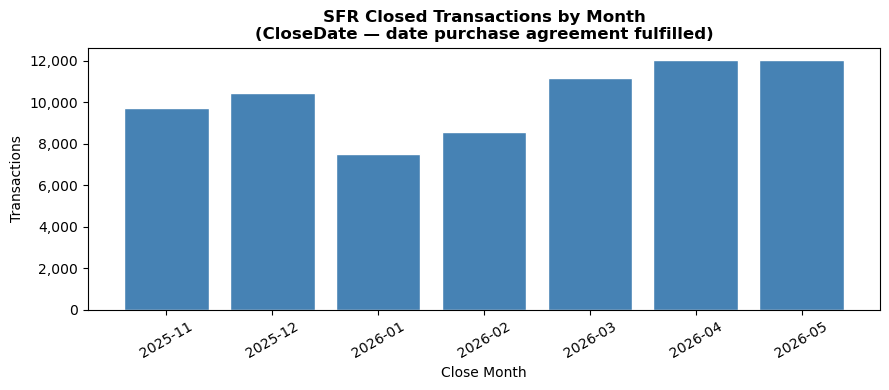

  Month  Transactions
2025-11          9739
2025-12         10455
2026-01          7490
2026-02          8550
2026-03         11177
2026-04         12031
2026-05         12024


In [16]:
# Monthly volume — using CloseDate (Trestle DateTime: date purchase agreement fulfilled)
monthly = df['CloseYearMonth'].value_counts().sort_index().reset_index()
monthly.columns = ['Month', 'Transactions']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly['Month'].astype(str), monthly['Transactions'],
       color='steelblue', edgecolor='white')
ax.set_title('SFR Closed Transactions by Month\n(CloseDate — date purchase agreement fulfilled)',
             fontweight='bold')
ax.set_xlabel('Close Month')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(monthly.to_string(index=False))

In [17]:
# PropertySubType breakdown of ALL Residential records — confirms SFR dominance
# Trestle: PropertySubType (PropertySubType Enum)
subtype_counts = raw[raw['PropertyType']=='Residential']['PropertySubType'].value_counts()
print('Residential PropertySubType breakdown (full dataset):')
print(subtype_counts.to_string())

Residential PropertySubType breakdown (full dataset):
PropertySubType
SingleFamilyResidence    71466
Condominium              15748
Townhouse                 5618
ManufacturedOnLand        1261
Duplex                     579
StockCooperative           354
Cabin                      112
Triplex                    106
MixedUse                    64
Quadruplex                  43
MobileHome                  32
BoatSlip                    23
OwnYourOwn                  11
ManufacturedHome             8
Loft                         7
Studio                       3
CoOwnership                  3
Timeshare                    3
Farm                         2
DeededParking                1


---
## 3. Target Variable: ClosePrice

**Trestle definition:** `ClosePrice` (Decimal 14.2) — *The amount of money paid by the purchaser to the seller for the property under the agreement.*  
This is the true transaction value — distinct from `ListPrice` (seller's ask) and `OriginalListPrice` (initial ask).

In [19]:
# Summary statistics
print('ClosePrice summary statistics:')
display(
    df['ClosePrice']
    .describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    .apply(lambda x: f'${x:,.0f}')
)

ClosePrice summary statistics:


count         $71,466
mean       $1,339,923
std        $7,387,074
min                $2
1%           $230,000
5%           $365,000
25%          $620,000
50%          $889,000
75%        $1,420,000
95%        $3,200,000
99%        $6,500,000
max      $796,000,000
Name: ClosePrice, dtype: object

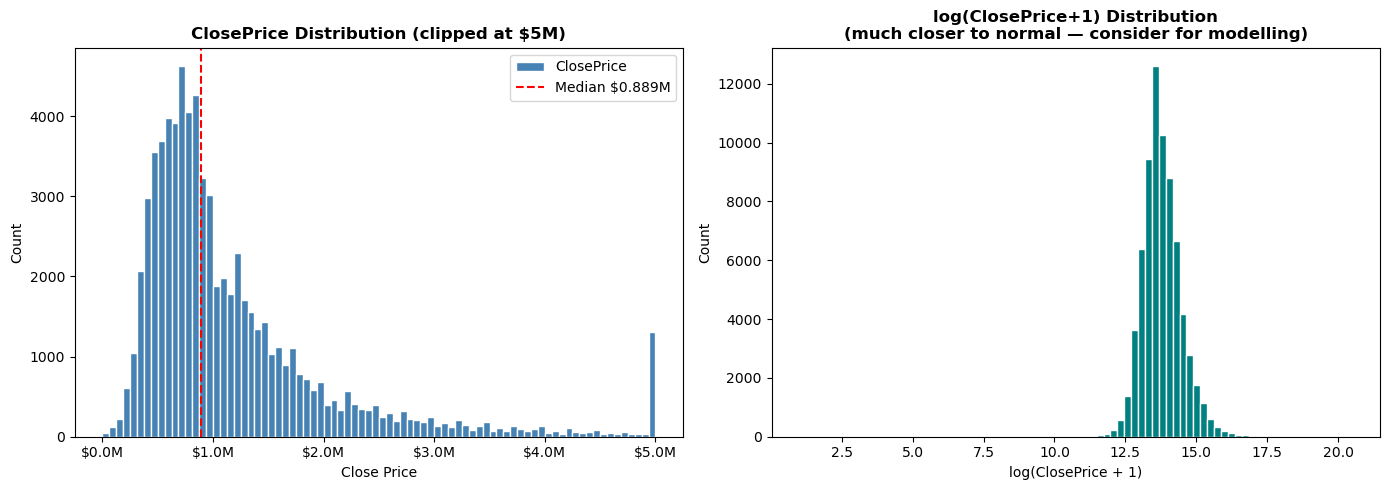

In [20]:
# Distribution: raw vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ClosePrice'].clip(upper=5_000_000).plot(
    kind='hist', bins=80, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(df['ClosePrice'].median(), color='red', linestyle='--',
                linewidth=1.5, label=f'Median ${df["ClosePrice"].median()/1e6:.3f}M')
axes[0].set_title('ClosePrice Distribution (clipped at $5M)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_xlabel('Close Price')
axes[0].set_ylabel('Count')
axes[0].legend()

np.log1p(df['ClosePrice']).plot(
    kind='hist', bins=80, ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('log(ClosePrice+1) Distribution\n(much closer to normal — consider for modelling)',
                  fontweight='bold')
axes[1].set_xlabel('log(ClosePrice + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [22]:
# Data quality flags on ClosePrice
print('ClosePrice data quality flags:')
print(f'  ClosePrice < $10k (likely data entry error): {(df["ClosePrice"] < 10_000).sum()} rows')
print(f'  ClosePrice > $10M (ultra-luxury — review):   {(df["ClosePrice"] > 10_000_000).sum()} rows')
print(f'  ClosePrice = $0 or null:                     {(df["ClosePrice"] <= 0).sum()} rows')
print()
print('Extreme low ClosePrice records:')
display(df[df['ClosePrice'] < 10_000][['ListingKey','ClosePrice','LivingArea','City','CloseDate']].head(10))

ClosePrice data quality flags:
  ClosePrice < $10k (likely data entry error): 4 rows
  ClosePrice > $10M (ultra-luxury — review):   288 rows
  ClosePrice = $0 or null:                     0 rows

Extreme low ClosePrice records:


,ListingKey,ClosePrice,LivingArea,City,CloseDate
50217,1144223437,1.75,3513.0,Palm Desert,2026-01-30
55713,1110035161,8300.00,3886.0,Altadena,2026-01-17
66917,1147508351,8000.00,984.0,Trona,2026-02-04
114423,1151459976,685.00,2980.0,Oakley,2026-04-29


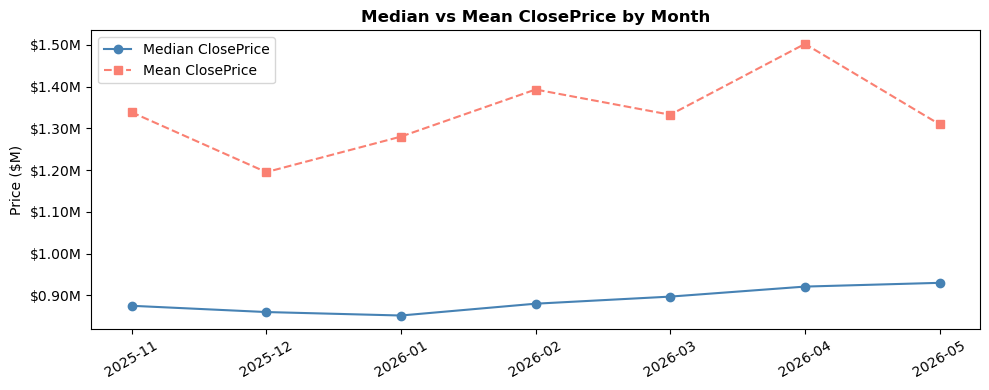

In [23]:
# Monthly median vs mean ClosePrice trend
# Mean > median confirms right skew from high-end properties
monthly_price = (
    df.groupby('CloseYearMonth')['ClosePrice']
    .agg(median='median', mean='mean', count='count')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_price['CloseYearMonth'].astype(str), monthly_price['median']/1e6,
        marker='o', color='steelblue', label='Median ClosePrice')
ax.plot(monthly_price['CloseYearMonth'].astype(str), monthly_price['mean']/1e6,
        marker='s', linestyle='--', color='salmon', label='Mean ClosePrice')
ax.set_title('Median vs Mean ClosePrice by Month', fontweight='bold')
ax.set_ylabel('Price ($M)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.2f}M'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 4. Size Features

LivingArea summary (Decimal 14.2 — total livable area):
count    71432.000000
mean      2053.831846
std       1038.535401
min          0.000000
25%       1387.000000
50%       1824.000000
75%       2451.000000
max      31068.000000
Name: LivingArea, dtype: float64

Records with LivingArea == 0 (data error): 20


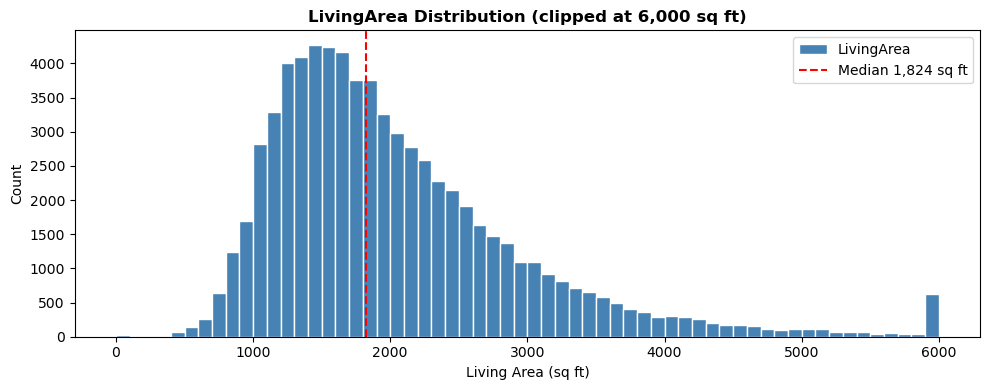

In [24]:
# LivingArea — Trestle Decimal 14.2: "The total livable area within the structure"
# NOTE: AboveGradeFinishedArea and BuildingAreaTotal are 100% null in this extract
# LivingArea is the only usable area field

print('LivingArea summary (Decimal 14.2 — total livable area):')
print(df['LivingArea'].describe())
print(f'\nRecords with LivingArea == 0 (data error): {(df["LivingArea"]==0).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
df['LivingArea'].clip(upper=6000).plot(
    kind='hist', bins=60, ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(df['LivingArea'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f'Median {df["LivingArea"].median():,.0f} sq ft')
ax.set_title('LivingArea Distribution (clipped at 6,000 sq ft)', fontweight='bold')
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

LotSizeSquareFeet summary (Decimal 14.2):
count    7.023900e+04
mean     4.813743e+05
std      2.122478e+07
min      0.000000e+00
25%      5.663000e+03
50%      7.260000e+03
75%      1.045400e+04
max      1.938943e+09
Name: LotSizeSquareFeet, dtype: float64


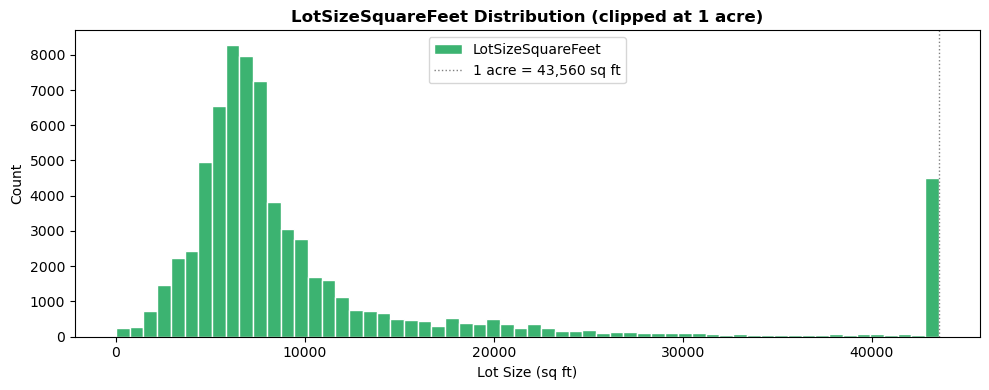

In [25]:
# LotSizeSquareFeet — Trestle Decimal 14.2
# Preferred over LotSizeAcres (redundant) and LotSizeArea (units defined separately)
# LotSizeDimensions is String 150 — freeform text, not usable for modelling

print('LotSizeSquareFeet summary (Decimal 14.2):')
print(df['LotSizeSquareFeet'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df['LotSizeSquareFeet'].dropna().clip(upper=43560).plot(   # 43560 = 1 acre
    kind='hist', bins=60, ax=ax, color='mediumseagreen', edgecolor='white'
)
ax.axvline(43560, color='gray', linestyle=':', linewidth=1, label='1 acre = 43,560 sq ft')
ax.set_title('LotSizeSquareFeet Distribution (clipped at 1 acre)', fontweight='bold')
ax.set_xlabel('Lot Size (sq ft)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Layout Features

BedroomsTotal == 0: 31 records (flag for review)


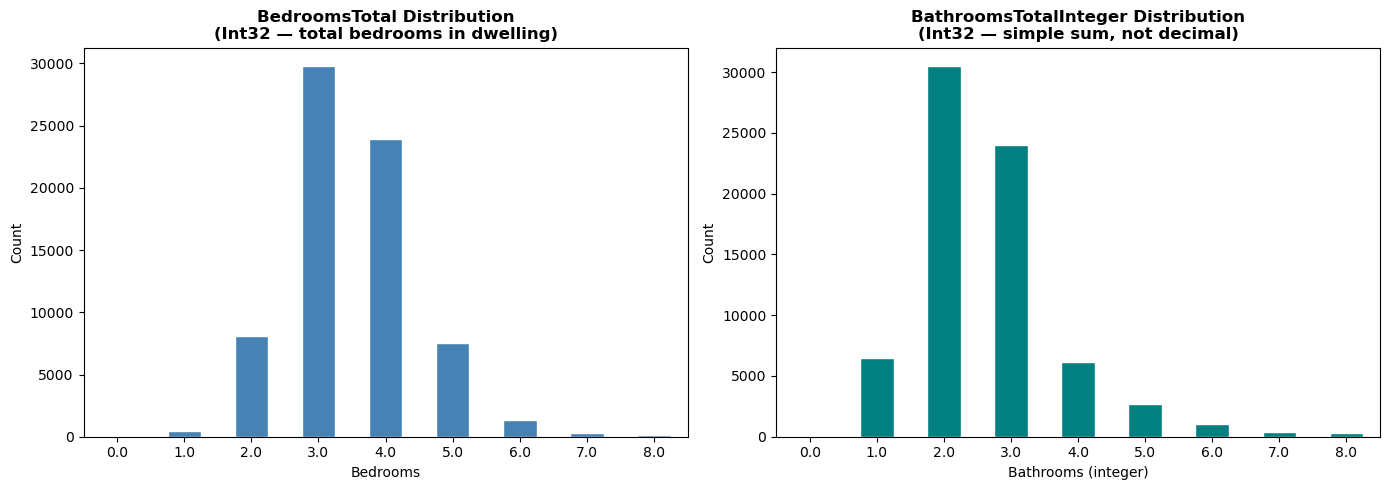

In [26]:
# BedroomsTotal — Trestle Int32: "The total number of bedrooms in the dwelling"
# BathroomsTotalInteger — Trestle Int32:
#   "The simple sum of the number of bathrooms. For a property with two Full and one Half,
#    BathroomsTotalInteger = 3. Decimal bathrooms (e.g. 2.5) require a non-standard field."

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

beds = df['BedroomsTotal'].clip(upper=8).value_counts().sort_index()
beds.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('BedroomsTotal Distribution\n(Int32 — total bedrooms in dwelling)',
                  fontweight='bold')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
print(f'BedroomsTotal == 0: {(df["BedroomsTotal"]==0).sum()} records (flag for review)')

baths = df['BathroomsTotalInteger'].clip(upper=8).value_counts().sort_index()
baths.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('BathroomsTotalInteger Distribution\n(Int32 — simple sum, not decimal)',
                  fontweight='bold')
axes[1].set_xlabel('Bathrooms (integer)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

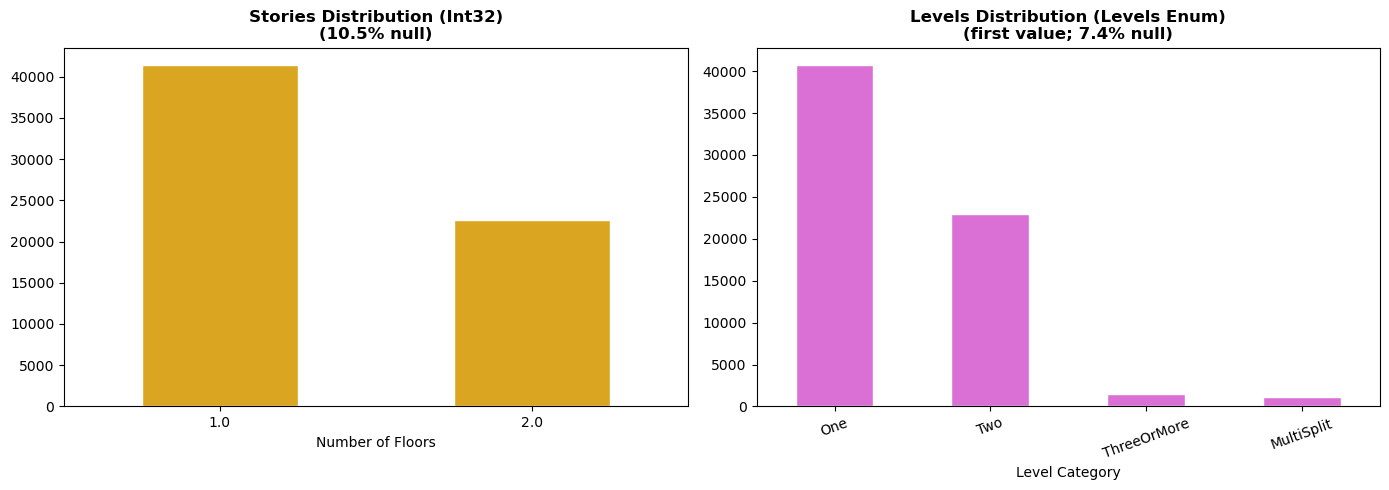

In [27]:
# Stories — Trestle Int32: "The number of floors in the property being sold"
# Levels — Trestle Levels Enum: descriptive version
#   Values: One, Two, ThreeOrMore, MultiSplit (and multi-value combinations)
# Both capture floors — Levels is better populated for low-null analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Stories'].dropna().clip(upper=5).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='goldenrod', edgecolor='white'
)
axes[0].set_title(f'Stories Distribution (Int32)\n(10.5% null)', fontweight='bold')
axes[0].set_xlabel('Number of Floors')
axes[0].tick_params(axis='x', rotation=0)

# Simplify Levels: take only the first value for multi-value records
df['Levels_primary'] = df['Levels'].str.split(',').str[0]
df['Levels_primary'].value_counts().head(6).plot(
    kind='bar', ax=axes[1], color='orchid', edgecolor='white'
)
axes[1].set_title('Levels Distribution (Levels Enum)\n(first value; 7.4% null)', fontweight='bold')
axes[1].set_xlabel('Level Category')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## 6. Age & Market Timing

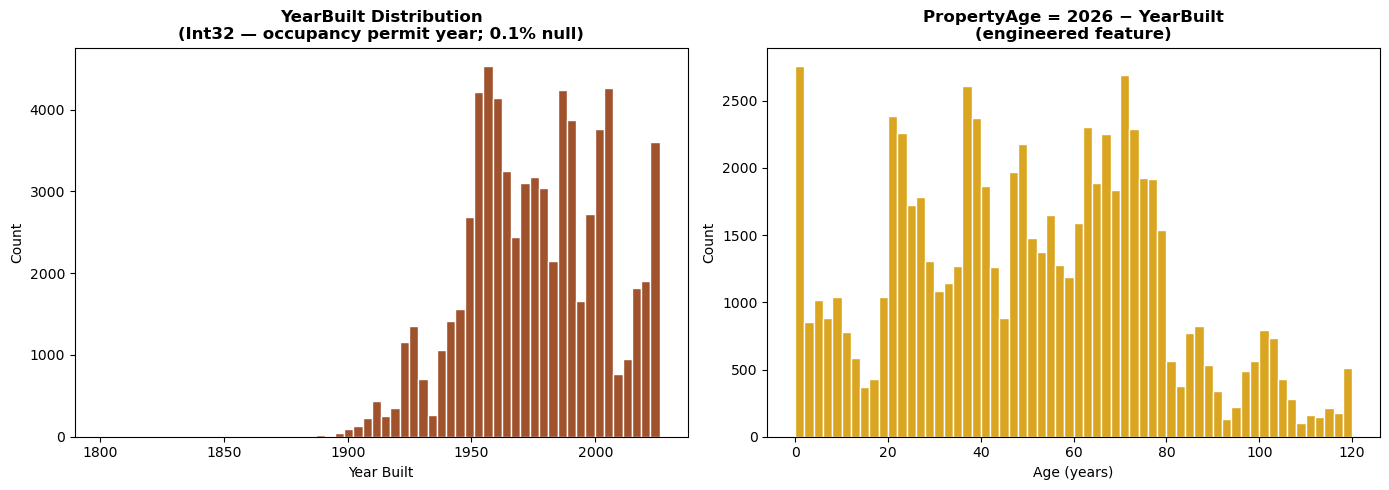

count    71425.000000
mean        49.797494
std         27.716933
min          0.000000
25%         27.000000
50%         49.000000
75%         70.000000
max        225.000000
Name: PropertyAge, dtype: float64


In [28]:
# YearBuilt — Trestle Int32:
#   "The year that an occupancy permit is first granted for the house."
# Engineer PropertyAge = 2026 - YearBuilt (feature for Week 3)

df['PropertyAge'] = 2026 - df['YearBuilt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['YearBuilt'].dropna().plot(
    kind='hist', bins=60, ax=axes[0], color='sienna', edgecolor='white'
)
axes[0].set_title('YearBuilt Distribution\n(Int32 — occupancy permit year; 0.1% null)',
                  fontweight='bold')
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('Count')

df['PropertyAge'].clip(lower=0, upper=120).plot(
    kind='hist', bins=60, ax=axes[1], color='goldenrod', edgecolor='white'
)
axes[1].set_title('PropertyAge = 2026 − YearBuilt\n(engineered feature)', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(df['PropertyAge'].describe())

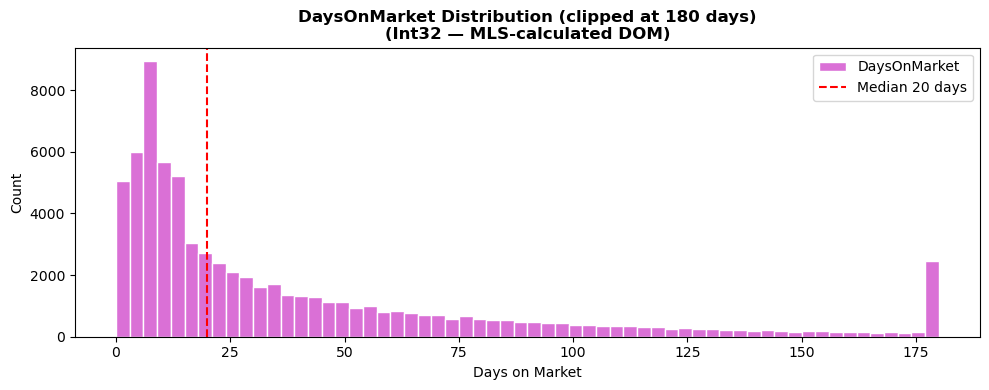

count    71466.000000
mean        41.758165
std         56.980593
min       -265.000000
25%          8.000000
50%         20.000000
75%         54.000000
max       2177.000000
Name: DaysOnMarket, dtype: float64


In [31]:
# DaysOnMarket — Trestle Int32:
#   "The number of days the listing is on market, as defined by the MLS business rules."
# Note: this is calculated by the MLS, not derived from ListingContractDate - CloseDate

fig, ax = plt.subplots(figsize=(10, 4))
df['DaysOnMarket'].clip(lower=0, upper=180).plot(
    kind='hist', bins=60, ax=ax, color='orchid', edgecolor='white'
)
ax.axvline(df['DaysOnMarket'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f'Median {df["DaysOnMarket"].median():.0f} days')
ax.set_title('DaysOnMarket Distribution (clipped at 180 days)\n(Int32 — MLS-calculated DOM)',
             fontweight='bold')
ax.set_xlabel('Days on Market')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(df['DaysOnMarket'].describe())

---
## 7. Price Signals: ListPrice & OriginalListPrice

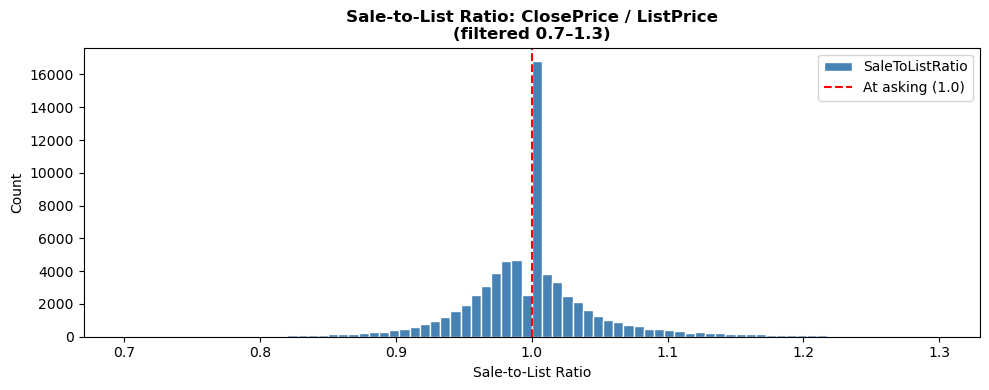

Median Sale-to-List Ratio : 1.000
% sold above asking       : 39.0%
% sold below asking       : 44.3%
% with price reduction    : 27.9%


In [32]:
# ListPrice — Trestle Decimal 14.2:
#   "The current price of the property as determined by the seller and seller's broker."
# OriginalListPrice — Trestle Decimal 14.2:
#   "The original price on the initial agreement between the seller and the seller's broker."
# When ListPrice < OriginalListPrice, a price reduction occurred before sale.

# Sale-to-List Ratio = ClosePrice / ListPrice
df['SaleToListRatio'] = df['ClosePrice'] / df['ListPrice']

# Price Reduction flag (engineered feature)
df['PriceReductionYN'] = df['ListPrice'] < df['OriginalListPrice']

stl_filtered = df[(df['SaleToListRatio'] >= 0.7) & (df['SaleToListRatio'] <= 1.3)]

fig, ax = plt.subplots(figsize=(10, 4))
stl_filtered['SaleToListRatio'].plot(
    kind='hist', bins=80, ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='At asking (1.0)')
ax.set_title('Sale-to-List Ratio: ClosePrice / ListPrice\n(filtered 0.7–1.3)', fontweight='bold')
ax.set_xlabel('Sale-to-List Ratio')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median Sale-to-List Ratio : {df["SaleToListRatio"].median():.3f}')
print(f'% sold above asking       : {(df["SaleToListRatio"] > 1.0).mean()*100:.1f}%')
print(f'% sold below asking       : {(df["SaleToListRatio"] < 1.0).mean()*100:.1f}%')
print(f'% with price reduction    : {df["PriceReductionYN"].mean()*100:.1f}%')

---
## 8. Boolean Amenity Features

/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_46039/709442578.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  true_pct = df[col].fillna(False).mean() * 100


,definition,null_pct,true_pct
field,,,
ViewYN,The property has a view,8.690846,56.846612
WaterfrontYN,The property is on the waterfront (99.9% null ...,99.948227,0.051773
BasementYN,Does the property have a basement? (97.6% null...,97.603056,2.396944
PoolPrivateYN,Privately owned pool included in sale,7.814905,15.492682
AttachedGarageYN,Garage attached to main/primary dwelling,12.155431,73.418129
FireplaceYN,Property includes a fireplace,0.088154,72.399463
NewConstructionYN,"Newly constructed, not previously occupied",7.550444,3.573727


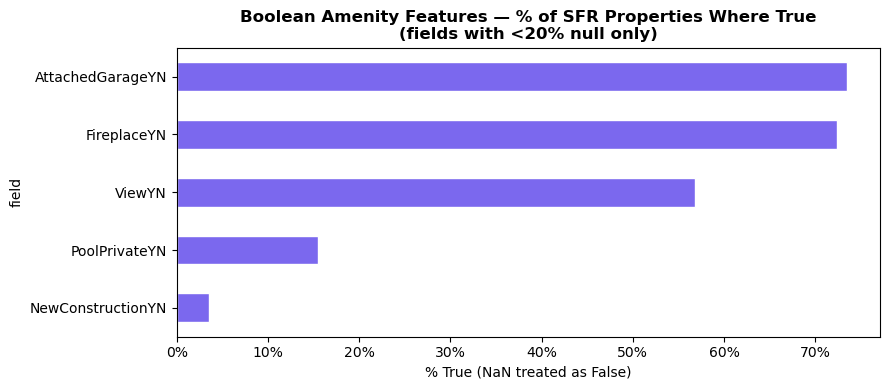

In [33]:
# All Boolean fields from Trestle schema — with null rates and true rates
# WaterfrontYN and BasementYN are nearly 100% null — will be dropped

bool_fields = {
    'ViewYN':          'The property has a view',
    'WaterfrontYN':    'The property is on the waterfront (99.9% null — DROP)',
    'BasementYN':      'Does the property have a basement? (97.6% null — DROP)',
    'PoolPrivateYN':   'Privately owned pool included in sale',
    'AttachedGarageYN':'Garage attached to main/primary dwelling',
    'FireplaceYN':     'Property includes a fireplace',
    'NewConstructionYN':'Newly constructed, not previously occupied',
}

bool_summary = []
for col, desc in bool_fields.items():
    if col in df.columns:
        null_pct = df[col].isna().mean() * 100
        true_pct = df[col].fillna(False).mean() * 100
        bool_summary.append({'field': col, 'definition': desc,
                              'null_pct': null_pct, 'true_pct': true_pct})

bool_df = pd.DataFrame(bool_summary).set_index('field')
display(bool_df)

# Plot true rates for usable fields only (null < 20%)
usable_bool = bool_df[bool_df['null_pct'] < 20]
fig, ax = plt.subplots(figsize=(9, 4))
usable_bool['true_pct'].sort_values().plot(
    kind='barh', ax=ax, color='mediumslateblue', edgecolor='white'
)
ax.set_title('Boolean Amenity Features — % of SFR Properties Where True\n(fields with <20% null only)',
             fontweight='bold')
ax.set_xlabel('% True (NaN treated as False)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

In [34]:
# ClosePrice premium for boolean features
print('Median ClosePrice by boolean amenity presence:')
for col in ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN', 'NewConstructionYN']:
    if col in df.columns:
        grp = df.copy()
        grp[col] = grp[col].fillna(False)
        prices = grp.groupby(col)['ClosePrice'].median()
        if True in prices.index and False in prices.index:
            premium = prices[True] - prices[False]
            print(f'  {col}: False=${prices[False]/1e6:.3f}M, True=${prices[True]/1e6:.3f}M '
                  f'(premium: ${premium:,.0f})')

Median ClosePrice by boolean amenity presence:


/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_46039/1701322814.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grp[col] = grp[col].fillna(False)


  PoolPrivateYN: False=$0.858M, True=$1.149M (premium: $291,000)
  ViewYN: False=$0.875M, True=$0.900M (premium: $25,000)
  FireplaceYN: False=$0.715M, True=$1.000M (premium: $285,000)
  AttachedGarageYN: False=$0.885M, True=$0.890M (premium: $5,000)
  NewConstructionYN: False=$0.900M, True=$0.665M (premium: $-234,785)


---
## 9. Categorical & Enum Features

In [35]:
# AssociationFee — Trestle Decimal 14.2: "A fee paid by homeowner to HOA"
# AssociationFeeFrequency — Trestle FeeFrequency Enum: Monthly/Annually/Quarterly/SemiAnnually
# 74% null on Frequency (and 28.6% null on Fee) → NaN likely means no HOA
# Strategy: normalize all fees to monthly equivalent

print('AssociationFeeFrequency value counts (FeeFrequency Enum):')
print(df['AssociationFeeFrequency'].value_counts())
print(f'\nNull: {df["AssociationFeeFrequency"].isna().sum():,} ({df["AssociationFeeFrequency"].isna().mean()*100:.1f}%) — treat as no HOA')

print('\nAssociationFee where > 0:')
print(df[df['AssociationFee'] > 0]['AssociationFee'].describe())

AssociationFeeFrequency value counts (FeeFrequency Enum):
AssociationFeeFrequency
Monthly         16371
Annually         1425
Quarterly         696
SemiAnnually      111
Name: count, dtype: int64

Null: 52,863 (74.0%) — treat as no HOA

AssociationFee where > 0:
count    18713.000000
mean       303.107258
std        566.944993
min          0.030000
25%        120.000000
50%        196.500000
75%        340.000000
max      20712.000000
Name: AssociationFee, dtype: float64


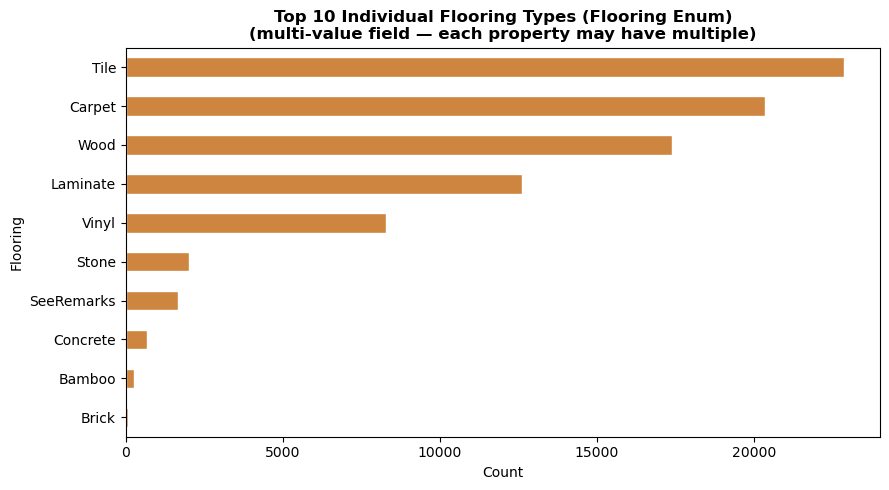

In [37]:
# Flooring — Trestle Flooring Enum: "A list of the type(s) of flooring found within the property"
# 235 unique combinations (comma-separated multi-value strings)
# Strategy: create binary flags for the most common individual floor types

# Extract individual flooring types from multi-value strings
flooring_exploded = df['Flooring'].dropna().str.split(',').explode().str.strip()
top_flooring = flooring_exploded.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top_flooring.sort_values().plot(kind='barh', ax=ax, color='peru', edgecolor='white')
ax.set_title('Top 10 Individual Flooring Types (Flooring Enum)\n(multi-value field — each property may have multiple)',
             fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

---
## 10. Geographic Distribution

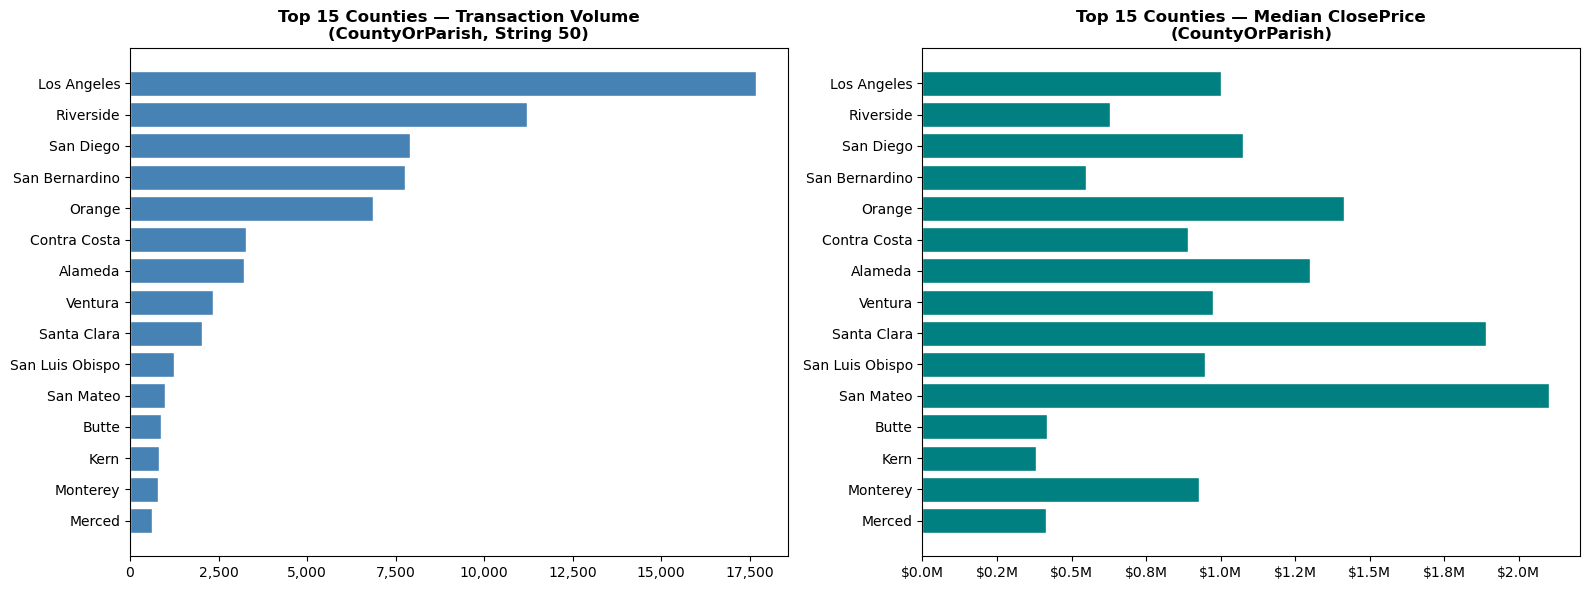

In [39]:
# CountyOrParish — Trestle String 50: "The County, Parish or other regional authority"
# 60 unique counties — good cardinality for a categorical feature

county_stats = (
    df.groupby('CountyOrParish')['ClosePrice']
    .agg(count='count', median_price='median')
    .sort_values('count', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(county_stats['CountyOrParish'], county_stats['count'],
             color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Counties — Transaction Volume\n(CountyOrParish, String 50)',
                  fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(county_stats['CountyOrParish'], county_stats['median_price']/1e6,
             color='teal', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Counties — Median ClosePrice\n(CountyOrParish)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.tight_layout()
plt.show()

In [40]:
# PostalCode — Trestle String 10: "The postal code portion of a street or mailing address"
# 1,675 unique ZIP codes — high cardinality; consider target encoding in Week 3

zip_stats = (
    df.groupby('PostalCode')['ClosePrice']
    .agg(count='count', median_price='median')
)
print(f'Unique PostalCodes (String 10): {df["PostalCode"].nunique():,}')
print(f'ZIP codes with fewer than 10 transactions: {(zip_stats["count"] < 10).sum()}')
print('\nTop 10 ZIP codes by volume:')
print(zip_stats.sort_values('count', ascending=False).head(10))

Unique PostalCodes (String 10): 1,675
ZIP codes with fewer than 10 transactions: 788

Top 10 ZIP codes by volume:
            count  median_price
PostalCode                     
92253         541      975000.0
92345         435      467090.0
92584         407      620000.0
92211         382      575000.0
92223         373      530000.0
92592         373      805000.0
92596         363      627590.0
92336         336      720500.0
92562         335      710000.0
93536         315      540000.0


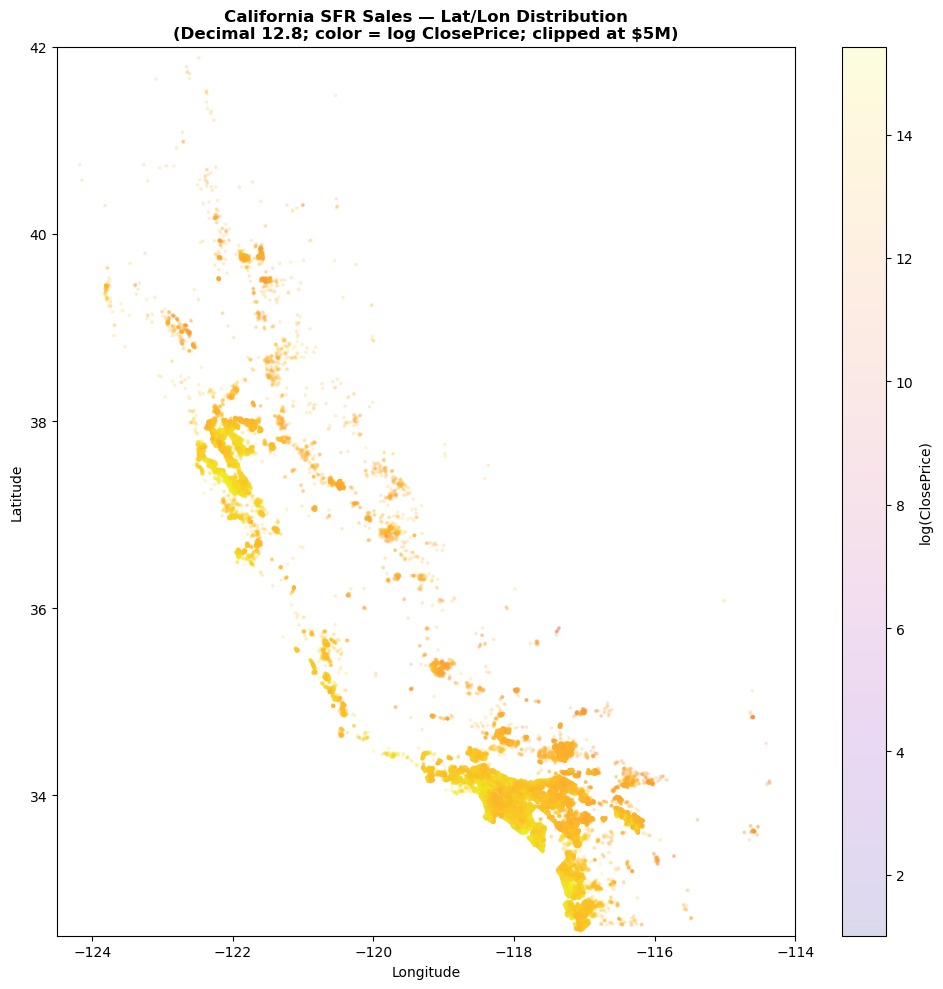

In [46]:
# Latitude / Longitude — Trestle Decimal 12.8:
#   "Geographic latitude/longitude of some reference point on the property"
# Use for: geographic scatter, distance features, school district spatial join (Week 6)

geo = df[df['ClosePrice'] < 5_000_000].dropna(subset=['Latitude', 'Longitude'])

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(
    geo['Longitude'], geo['Latitude'],
    c=np.log1p(geo['ClosePrice']), cmap='plasma',
    alpha=0.15, s=3
)
plt.colorbar(sc, ax=ax, label='log(ClosePrice)')
ax.set_title('California SFR Sales — Lat/Lon Distribution\n'
             '(Decimal 12.8; color = log ClosePrice; clipped at $5M)',
             fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Restrict to California bounding box
ax.set_xlim(-124.5, -114.0)
ax.set_ylim(32.5, 42.0)

plt.tight_layout()
plt.show()

In [42]:
# HighSchoolDistrict — Trestle String 50:
#   "The name of the high school district having a catchment area that includes the property.
#    When only one school district is used, this field should be used over Junior or Elementary."
# 26.9% null — will be supplemented by spatial join in Week 6

print(f'HighSchoolDistrict: {df["HighSchoolDistrict"].nunique()} unique values, '
      f'{df["HighSchoolDistrict"].isna().mean()*100:.1f}% null')
print()
print('Top 15 HighSchoolDistricts by volume:')
hsd = df.groupby('HighSchoolDistrict')['ClosePrice'].agg(count='count', median='median')
print(hsd.sort_values('count', ascending=False).head(15))

# Note: ElementarySchoolDistrict and MiddleOrJuniorSchoolDistrict are 100% null
# ElementarySchool (87.3% null), MiddleOrJuniorSchool (87.2% null), HighSchool (83.2% null)
# → Only HighSchoolDistrict is usable from the school fields in this extract

HighSchoolDistrict: 400 unique values, 26.9% null

Top 15 HighSchoolDistricts by volume:
                             count     median
HighSchoolDistrict                           
Los Angeles Unified           4305   920000.0
Other                         4257  1424000.0
Capistrano Unified            1326  1700000.0
Riverside Unified              912   680000.0
Corona-Norco Unified           838   840000.0
Long Beach Unified             818   965000.0
William S. Hart Union          796   875000.0
Hemet Unified                  778   474000.0
Temecula Unified               740   755000.0
San Bernardino City Unified    726   525000.0
Perris Union High              694   585000.0
Saddleback Valley Unified      662  1355000.0
Antelope Valley Union          655   489000.0
Lake Elsinore Unified          616   649000.0
San Diego Unified              606  1047500.0


---
## 11. Correlation with ClosePrice

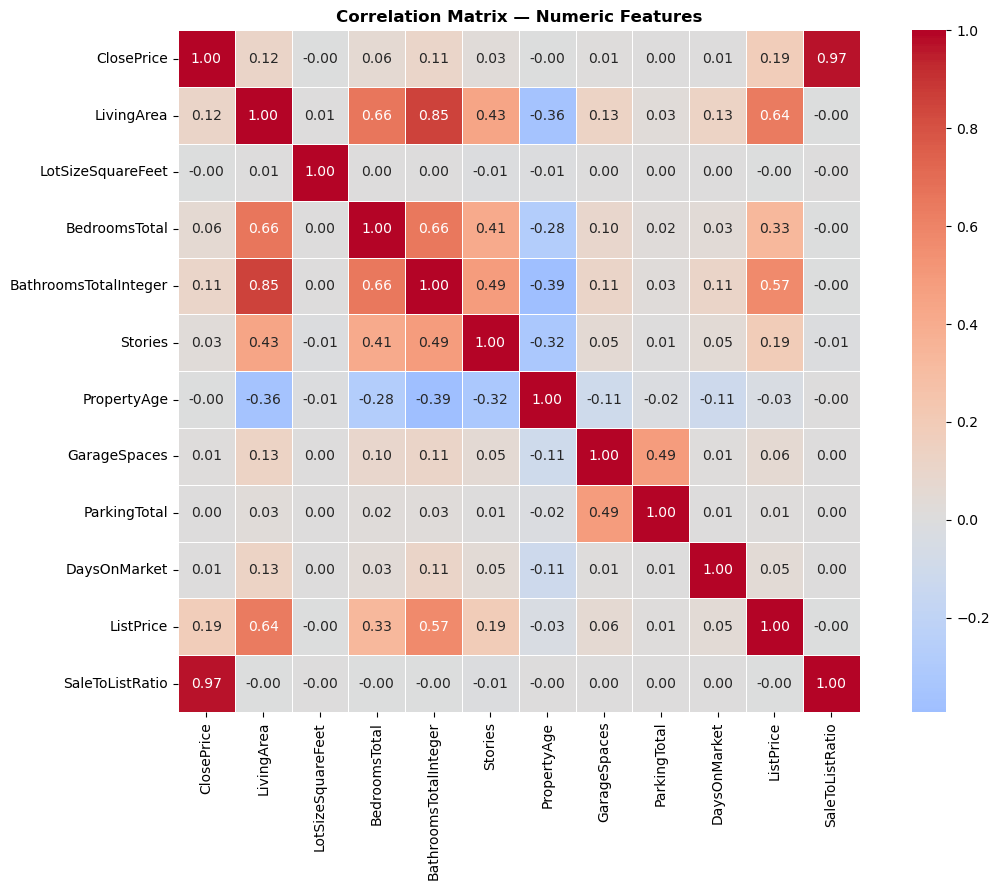

In [43]:
# Numeric features confirmed present and usable from Trestle schema
NUMERIC_FEATURES = [
    'ClosePrice',
    'LivingArea',           # Decimal 14.2 — total livable area
    'LotSizeSquareFeet',    # Decimal 14.2 — total lot area
    'BedroomsTotal',        # Int32 — total bedrooms
    'BathroomsTotalInteger',# Int32 — simple sum of bathrooms
    'Stories',              # Int32 — number of floors
    'PropertyAge',          # engineered from YearBuilt (Int32)
    'GarageSpaces',         # Decimal 14.2 — number of garage spaces
    'ParkingTotal',         # Decimal 14.2 — total spaces
    'DaysOnMarket',         # Int32 — MLS-calculated DOM
    'ListPrice',            # Decimal 14.2 — current asking price
    'SaleToListRatio',      # engineered: ClosePrice / ListPrice
]

corr = df[NUMERIC_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

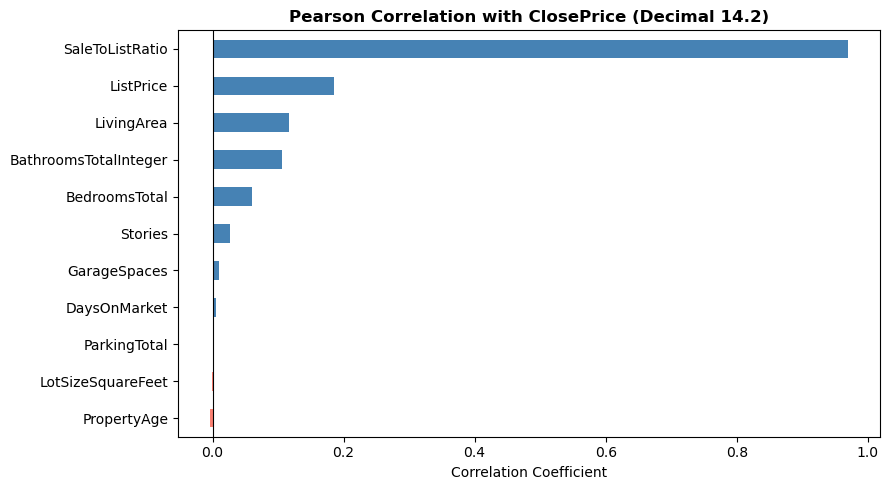

In [44]:
# Sorted bar: correlation with ClosePrice
cp_corr = corr['ClosePrice'].drop('ClosePrice').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
cp_corr.plot(
    kind='barh', ax=ax,
    color=cp_corr.map(lambda x: 'steelblue' if x > 0 else 'salmon')
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with ClosePrice (Decimal 14.2)', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

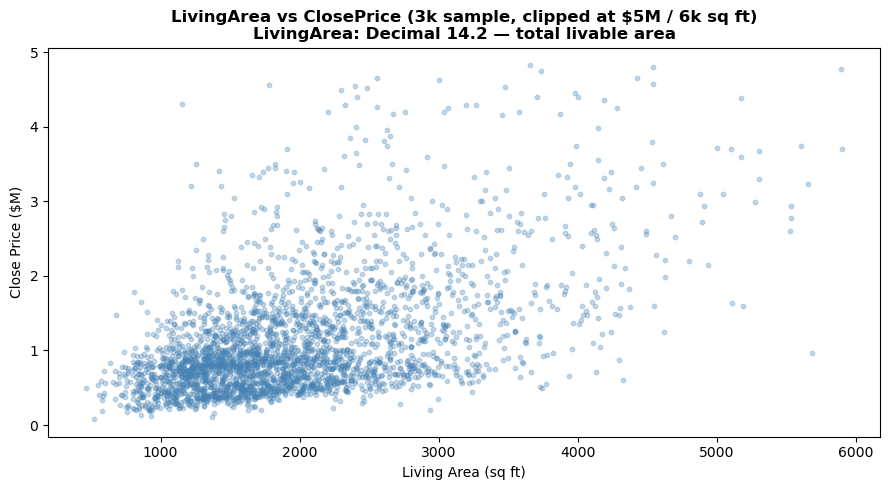

In [45]:
# LivingArea vs ClosePrice — the core size/price relationship
sample = df[
    (df['ClosePrice'] < 5_000_000) &
    (df['LivingArea'] > 0) &
    (df['LivingArea'] < 6000)
].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['LivingArea'], sample['ClosePrice']/1e6,
           alpha=0.3, s=10, color='steelblue')
ax.set_title('LivingArea vs ClosePrice (3k sample, clipped at $5M / 6k sq ft)\n'
             'LivingArea: Decimal 14.2 — total livable area',
             fontweight='bold')
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Close Price ($M)')
plt.tight_layout()
plt.show()

---
## 12. EDA Summary & Week 3 Preprocessing Plan

### Dataset Snapshot

| Item | Value |
|---|---|
| Total rows (all PropertyTypes) | 143,492 |
| Rows after SFR filter | 71,466 |
| Date range (CloseDate) | Nov 2025 – May 2026 |
| Trestle columns | 78 |
| Columns 100% null in this extract | 8 (drop) |
| ClosePrice median | $889,000 |
| ClosePrice p1–p99 | $230k – $6.5M |
| Median LivingArea | 1,824 sq ft |
| Median DaysOnMarket | See output above |
| Median YearBuilt | 1977 (median PropertyAge ~49 yrs) |

### Fields to DROP (from modelling)

| Field | Reason |
|---|---|
| `AboveGradeFinishedArea` | 100% null in this extract |
| `BelowGradeFinishedArea` | 99.3% null |
| `BuildingAreaTotal` | 93.3% null |
| `TaxAnnualAmount` | 100% null |
| `CoveredSpaces` | 100% null |
| `FireplacesTotal` | 100% null (use `FireplaceYN` instead) |
| `BusinessType` | 100% null — not applicable to SFR |
| `ElementarySchoolDistrict` | 100% null |
| `MiddleOrJuniorSchoolDistrict` | 100% null |
| `WaterfrontYN` | 99.9% null |
| `BasementYN` | 97.6% null |
| `ElementarySchool` | 87.3% null |
| `MiddleOrJuniorSchool` | 87.2% null |
| `HighSchool` | 83.2% null (use `HighSchoolDistrict`) |
| `LotSizeAcres` / `LotSizeArea` | Redundant with `LotSizeSquareFeet` |
| `LotSizeDimensions` | Freeform String 150 — not modelable |
| `MainLevelBedrooms` | 39.0% null; overlaps `BedroomsTotal` |

### Imputation Plan

| Field | Strategy |
|---|---|
| `LotSizeSquareFeet` (1.7% null) | Impute with ZIP-level median |
| `GarageSpaces` (3.9% null) | Impute 0 — no garage |
| `Stories` (10.5% null) | Impute with mode (=1) or derive from `Levels_primary` |
| `PoolPrivateYN` (7.8% null) | Impute False |
| `ViewYN` (8.7% null) | Impute False |
| `AttachedGarageYN` (12.2% null) | Impute False |
| `NewConstructionYN` (7.6% null) | Impute False |
| `AssociationFee` (28.6% null) | Impute 0 — no HOA |
| `AssociationFeeFrequency` (74% null) | Impute 'None' — normalize fee to monthly |
| `HighSchoolDistrict` (26.9% null) | Supplement with spatial join (Week 6) |
| `Flooring` (36.3% null) | Create binary flags for top types; null → 'Unknown' |

### Feature Engineering Plan (Week 3)

| Feature | Formula | Source Fields |
|---|---|---|
| `PropertyAge` | `2026 - YearBuilt` | `YearBuilt` (Int32) |
| `BedBathRatio` | `BedroomsTotal / BathroomsTotalInteger` | Both Int32 |
| `PricePerSqFt` | `ClosePrice / LivingArea` (exploratory only) | Both Decimal 14.2 |
| `SaleToListRatio` | `ClosePrice / ListPrice` | Both Decimal 14.2 |
| `PriceReductionYN` | `ListPrice < OriginalListPrice` | Both Decimal 14.2 |
| `MonthlyHOA` | Normalize `AssociationFee` by `AssociationFeeFrequency` | Decimal + Enum |
| `Levels_primary` | First value from `Levels` enum (One/Two/ThreeOrMore/MultiSplit) | Levels Enum |
| `Flooring_*` | Binary flags: `Flooring_Wood`, `Flooring_Tile`, etc. | Flooring Enum |

### Outlier Flags (to resolve in Week 3)

| Flag | Count | Action |
|---|---|---|
| `ClosePrice < $10k` | 4 | Drop — likely data entry errors |
| `ClosePrice > $10M` | 288 | Review; may cap at 99th percentile or keep with log transform |
| `LivingArea == 0` | 20 | Drop — structural data error |
| `BedroomsTotal == 0` | 31 | Review individually |

### Train / Test Split (Week 3)
- **Test set:** May 2026 (`CRMLSSold202605.csv`) — most recent month, ~12,024 SFR rows
- **Training set:** Nov 2025 – Apr 2026 — ~59,442 SFR rows
- Window length (how many months to include) is a tunable hyperparameter — experiment in Week 4+

### To-Do Before Running Week 3
- [ ] Drop all 100%-null columns listed above
- [ ] Drop 4 rows with `ClosePrice < $10k` and 20 rows with `LivingArea == 0`
- [ ] Apply all imputation strategies in the table above
- [ ] Engineer all features in the engineering plan
- [ ] Encode `PostalCode`, `CountyOrParish`, `City` (target encoding or ordinal)
- [ ] Encode `Levels_primary` as ordinal (One=1, Two=2, ThreeOrMore=3, MultiSplit=2)
- [ ] Save cleaned dataset to `data/cleaned/sfr_cleaned.csv`